### Private SLI Predictions



Preprocessing complete.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:11:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


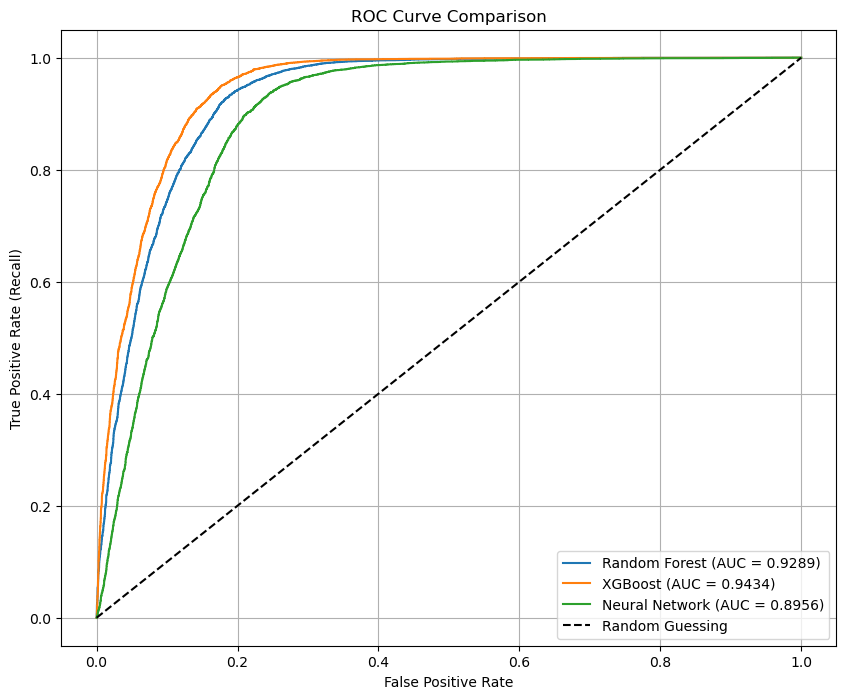

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler

df = pd.read_csv("data.csv")

df = df[df['Public Service Line Material'].isin(['LEAD', 'NOT LEAD'])]
df['Public Service Line Material'] = df['Public Service Line Material'].map({'LEAD': 1, 'NOT LEAD': 0})

categorical_features = [
    'Wall Material', 'Roof Material', 'Basement', 'Basement Finish', 
    'Central Air Conditioning', 'Garage 1 Material', 'Garage 1 Size', 'Garage 1 Attached', 
    'Use', 'Type of Residence', 'Flood Risk Factor', 'withinmr100',
    'school_elem_district', 'school_hs_district', 'township_name', 
    'Central Heating', 'FEMA Floodplain', 'Repair Condition', 'withinmr101300'
]

numerical_features = [
    'Land Square Feet', 'Age', 'Rooms', 'Full Baths',
    'Half Baths', 'Garage 1 Area', 'Building Square Feet', 'longitude',
    'latitude', 'tract_pop', 'tract_white_perc', 'tract_black_perc', 'tract_asian_perc', 
    'tract_his_perc', 'tract_other_perc', 'Tract Median Income', 'Bedrooms', 'Fireplaces'
]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])

X = df.drop(columns=['Public Service Line Material'])
y = df['Public Service Line Material']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete.")

ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X_train_processed, y_train)


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)


xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_processed, y_train)


nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=500,
    early_stopping=True,
    random_state=0
)
nn.fit(X_resampled, y_resampled)  

rf_probs = rf.predict_proba(X_test_processed)[:, 1]
xgb_probs = xgb.predict_proba(X_test_processed)[:, 1]
nn_probs = nn.predict_proba(X_test_processed)[:, 1]


rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs)

rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)
nn_auc = roc_auc_score(y_test, nn_probs)


plt.figure(figsize=(10, 8))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot(nn_fpr, nn_tpr, label=f'Neural Network (AUC = {nn_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:22:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:23:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:23:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [20:24:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

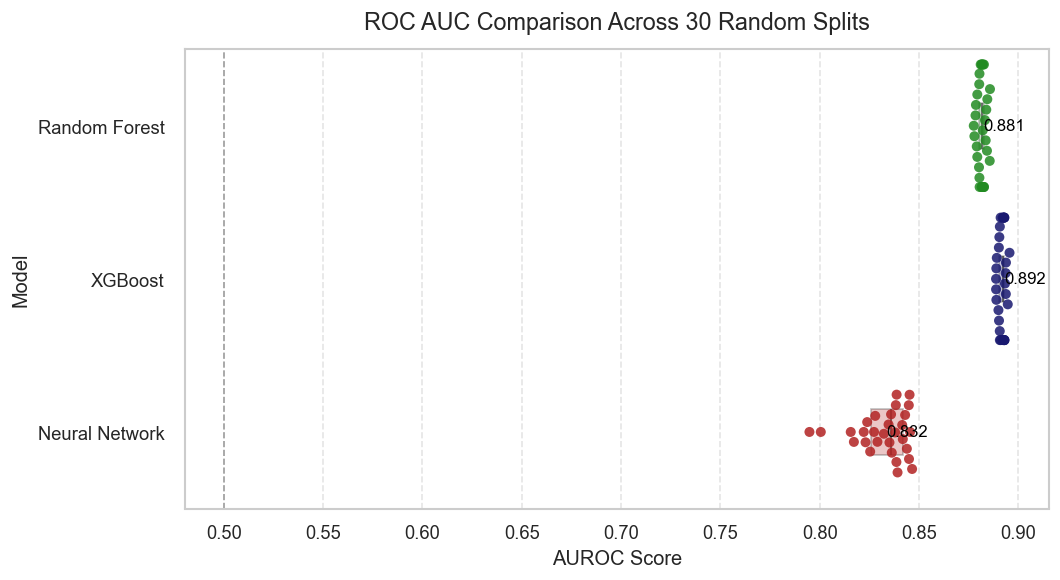

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import RandomOverSampler

df = pd.read_csv("data.csv")

df = df[df['Private Service Line Material'].isin(['LEAD', 'NOT LEAD'])]
df['Private Service Line Material'] = df['Private Service Line Material'].map({'LEAD': 1, 'NOT LEAD': 0})

categorical_features = [
    'Wall Material', 'Roof Material', 'Basement', 'Basement Finish', 
    'Central Air Conditioning', 'Garage 1 Material', 'Garage 1 Size', 'Garage 1 Attached', 
    'Use', 'Type of Residence', 'Flood Risk Factor', 'withinmr100',
    'school_elem_district', 'school_hs_district', 'township_name', 
    'Central Heating', 'FEMA Floodplain', 'Repair Condition', 'withinmr101300'
]

numerical_features = [
    'Land Square Feet', 'Age', 'Rooms', 'Full Baths',
    'Half Baths', 'Garage 1 Area', 'Building Square Feet', 'longitude',
    'latitude', 'tract_pop', 'tract_white_perc', 'tract_black_perc', 'tract_asian_perc', 
    'tract_his_perc', 'tract_other_perc', 'Tract Median Income', 'Bedrooms', 'Fireplaces'
]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])


results = []

for run in range(30):
    X = df.drop(columns=['Private Service Line Material'])
    y = df['Private Service Line Material']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=run  
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    ros = RandomOverSampler(random_state=run)
    X_resampled, y_resampled = ros.fit_resample(X_train_processed, y_train)

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=run,
        n_jobs=-1
    )
    rf.fit(X_train_processed, y_train)
    rf_probs = rf.predict_proba(X_test_processed)[:, 1]
    rf_auc = roc_auc_score(y_test, rf_probs)
    results.append({'Model': 'Random Forest', 'AUROC': rf_auc})

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=run,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb.fit(X_train_processed, y_train)
    xgb_probs = xgb.predict_proba(X_test_processed)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_probs)
    results.append({'Model': 'XGBoost', 'AUROC': xgb_auc})

    nn = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        max_iter=500,
        early_stopping=True,
        random_state=run
    )
    nn.fit(X_resampled, y_resampled)
    nn_probs = nn.predict_proba(X_test_processed)[:, 1]
    nn_auc = roc_auc_score(y_test, nn_probs)
    results.append({'Model': 'Neural Network', 'AUROC': nn_auc})


results_df = pd.DataFrame(results)


model_order = ['Random Forest', 'XGBoost', 'Neural Network']
palette = {
    'Random Forest': 'forestgreen',
    'XGBoost': 'midnightblue',
    'Neural Network': 'firebrick'
}

plt.figure(figsize=(9, 5), dpi=120)
sns.set(style="whitegrid", context="notebook")

sns.swarmplot(
    data=results_df,
    y='Model',
    x='AUROC',
    order=model_order,
    palette=palette,
    size=6,
    alpha=0.85
)

for model in model_order:
    sns.boxplot(
        data=results_df[results_df['Model'] == model],
        y='Model',
        x='AUROC',
        width=0.3,
        order=[model],
        showcaps=False,
        boxprops=dict(facecolor=palette[model], alpha=0.25, edgecolor='black'),
        whiskerprops=dict(linewidth=0),
        fliersize=0
    )

for i, model in enumerate(model_order):
    model_data = results_df[results_df['Model'] == model]['AUROC']
    mean_val = model_data.mean()
    plt.text(mean_val + 0.001, i, f"{mean_val:.3f}", va='center', fontsize=10, color='black')

plt.title("ROC AUC Comparison Across 30 Random Splits", fontsize=14, pad=12)
plt.xlabel("AUROC Score")
plt.ylabel("Model")
plt.tick_params(axis='y', pad=6)

plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()